In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
def demoRlsImplEqual():
  np.random.seed(42)

  # -----------------------------
  # Problem setup
  # -----------------------------
  N = 2000
  n_coef = 4

  # true system (complex)
  w_true = np.array([0.5+0.2j, -0.3+0.1j, 0.2-0.4j, 0.1+0.05j], dtype=np.complex64)

  # input signal
  x = (np.random.randn(N) + 1j*np.random.randn(N)).astype(np.complex64)

  # desired signal
  x_pad = np.pad(x, (n_coef-1, 0))
  d = np.zeros(N, dtype=np.complex64)

  for k in range(N):
    reg = x_pad[k:k+n_coef][::-1]
    d[k] = np.vdot(w_true, reg)

  # add small noise
  noise = 0.01*(np.random.randn(N) + 1j*np.random.randn(N))
  d += noise.astype(np.complex64)

  # -----------------------------
  # Instantiate both filters
  # -----------------------------
  rls1 =  adspfilter.RLS(mu=None, filter_order=n_coef-1, lam=0.995, delta=1e-2)
  rls2 =  adspfilter.RLSAlt(mu=None, filter_order=n_coef-1, lam=0.995, delta=1e-2)

  # -----------------------------
  # Run filters
  # -----------------------------
  y1, e1, w_hist1 = rls1(x, d, train=True)
  y2, e2, w_hist2 = rls2(x, d, train=True)

  # -----------------------------
  # Compare final weights
  # -----------------------------
  print("\n=== FINAL WEIGHTS ===")
  print("True w:     ", w_true)
  print("RLS w:      ", rls1.w)
  print("RLSAlt w:   ", rls2.w)

  # difference
  diff = np.linalg.norm(rls1.w - rls2.w)
  print("\n||RLS - RLSAlt|| =", diff)

  # -----------------------------
  # MSE convergence
  # -----------------------------
  mse1 = np.abs(e1)**2
  mse2 = np.abs(e2)**2

  # smooth
  win = 50
  mse1_s = np.convolve(mse1, np.ones(win)/win, mode='valid')
  mse2_s = np.convolve(mse2, np.ones(win)/win, mode='valid')

  # -----------------------------
  # Weight error norm
  # -----------------------------
  err_w1 = np.linalg.norm(w_hist1 - w_true, axis=1)
  err_w2 = np.linalg.norm(w_hist2 - w_true, axis=1)

  # -----------------------------
  # Plots
  # -----------------------------
  plt.figure(figsize=(12,5))

  plt.subplot(1,2,1)
  plt.plot(mse1_s, label="RLS")
  plt.plot(mse2_s, '--', label="RLSAlt")
  plt.title("MSE convergence")
  plt.yscale("log")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(err_w1, label="RLS")
  plt.plot(err_w2, '--', label="RLSAlt")
  plt.title("Weight error norm")
  plt.yscale("log")
  plt.legend()

  plt.tight_layout()
  plt.show()

  # -----------------------------
  # Assertion test
  # -----------------------------
  assert diff < 1e-3, "RLS and RLSAlt diverged!"

  print("\nPASS: Both implementations match ✔")



=== FINAL WEIGHTS ===
True w:      [ 0.5+0.2j  -0.3+0.1j   0.2-0.4j   0.1+0.05j]
RLS w:       [ 0.5001893 +0.2002083j  -0.29988524+0.10030609j  0.20047465-0.39920953j
  0.09950695+0.05030479j]
RLSAlt w:    [ 0.5002391 +0.20036294j -0.2998387 +0.10032291j  0.20016018-0.3990903j
  0.09953462+0.05061879j]

||RLS - RLSAlt|| = 0.0004912321


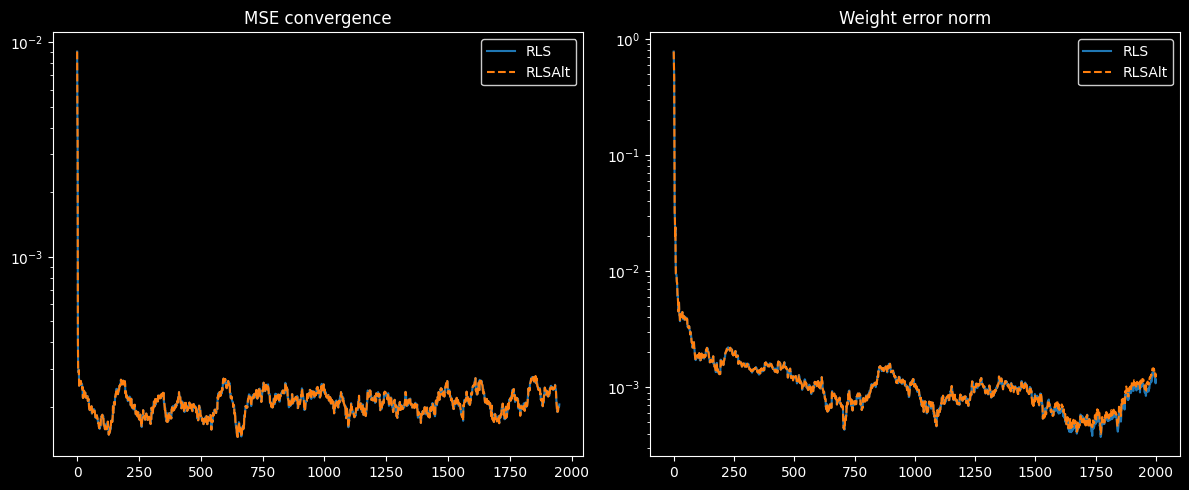


PASS: Both implementations match ✔


In [3]:
demoRlsImplEqual()